# New Project: Child Malnutrition in Kenya (1993-2022)
## Project Overview
We'll analyze how child malnutrition (stunting, wasting, underweight) has changed in Kenya over 30 years and what factors explain these changes.

Step 1: Problem Definition and Research Questions
Why This Matters
Child malnutrition affects:

Physical development

Cognitive development

Future earning potential

Overall health throughout life

Understanding trends and causes helps target interventions.

### Our Research Questions
1. How have malnutrition rates changed in Kenya from 1993 to 2022?

- Stunting (chronic malnutrition)

- Wasting (acute malnutrition)

- Underweight (combined measure)

2. What's the relationship between malnutrition and:

- Maternal education?

- Household water source?

- Sanitation facilities?

- Household wealth (electricity, TV, fridge)?

3. Which factors are most strongly associated with improvements in child nutrition?

4. Are there different patterns for stunting vs wasting? (They measure different things)

### Our Hypotheses
H1: All forms of malnutrition have declined over time

H2: Higher maternal education is associated with lower malnutrition

H3: Better water and sanitation correlate with better nutrition

H4: Wealthier households have better-nourished children

H5: Stunting (long-term) responds slower to improvements than wasting (short-term)

## Step 2: Identify Our Datasets
We'll use:

Dataset	Key Variables

|select-nutrition-indicators_national_ken.csv	| Stunting, wasting, underweight (targets)    |  

|select-education-indicators_national_ken.csv	| Maternal education, literacy                |  
   
|water_national_ken.csv	                        | Improved water source access                |  
 
|toilet-facilities_national_ken.csv              |  Improved sanitation access                |  
 
|covid-19-additional-factors_national_ken.csv    |   Electricity, TV, fridge (wealth proxies) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load nutrition data (skipping the second header row)
nutrition = pd.read_csv('select-nutrition-indicators_national_ken.csv', 
                        header=0, skiprows=[1])

# Clean column names
nutrition.columns = [col.replace('#', '').replace('+', '_').lower() 
                     for col in nutrition.columns]

# Remove unnamed columns
nutrition = nutrition.loc[:, ~nutrition.columns.str.contains('^unnamed')]

print("NUTRITION DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {nutrition.shape}")
print(f"\nYears available: {sorted(nutrition['surveyyear'].unique())}")

print("\nKey malnutrition indicators:")
key_nutrition = ['cn_nuts_c_ha2', 'cn_nuts_c_wh2', 'cn_nuts_c_wa2']  # stunting, wasting, underweight
available = nutrition[nutrition['indicatorid'].isin(key_nutrition)]
print(available[['surveyyear', 'indicatorid', 'indicator', 'value']].to_string())

NUTRITION DATASET OVERVIEW
Shape: (59, 29)

Years available: [np.int64(1989), np.int64(1993), np.int64(1998), np.int64(2003), np.int64(2008), np.int64(2014), np.int64(2022)]

Key malnutrition indicators:
Empty DataFrame
Columns: [surveyyear, indicatorid, indicator, value]
Index: []


In [2]:
# Let's see all unique indicator IDs in the nutrition dataset
print("All indicator IDs in nutrition dataset:")
print("-" * 50)
unique_indicators = nutrition['indicatorid'].unique()
for ind in sorted(unique_indicators):
    # Get one example row to see the indicator name
    example = nutrition[nutrition['indicatorid'] == ind].iloc[0]
    print(f"{ind}: {example['indicator']}")

All indicator IDs in nutrition dataset:
--------------------------------------------------
AN_MIAM_W_90P: Women with a birth in the past five years who took iron tablets or syrup for 90+ days
AN_NUTS_W_OWT: Women who are overweight or obese according to BMI (>=25.0)
AN_NUTS_W_THN: Women who are thin according to BMI (<18.5)
CN_BRFI_C_1HR: Children who started breastfeeding within 1 hour of birth
CN_BRFS_C_BRF: Children currently breastfeeding
CN_BRFS_C_EXB: Children exclusively breastfed
CN_IODZ_H_IOD: Households with iodized salt
CN_IYCF_C_3PN: Non-breastfed children 6-23 months with 3 IYCF practices
CN_IYCF_C_BTB: Breastfed children 6-23 months fed both 4+ food groups and the minimum meal frequency
CN_NUTS_C_HA2: Children stunted
CN_NUTS_C_WH2: Children wasted
CN_NUTS_C_WHP: Children overweight


Extracting malnutrition indicators

MALNUTRITION RATES OVER TIME (%)
indicator  overweight  stunting  wasting
year                                    
1993              5.7      39.9      6.7
1998              6.3      37.7      6.9
2003              5.5      35.7      6.0
2008              4.7      35.3      6.7
2014              4.1      26.0      4.0
2022              3.2      17.6      4.9

CHANGE FROM FIRST TO LAST YEAR (percentage points)
Period: 1993 to 2022
indicator
overweight    -2.5
stunting     -22.3
wasting       -1.8
dtype: float64


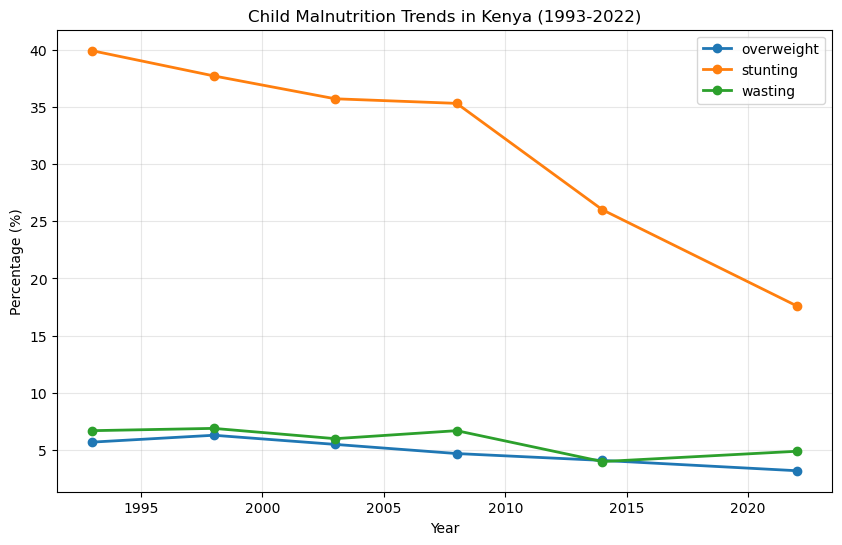

In [3]:
# Extract malnutrition indicators
malnutrition_indicators = ['CN_NUTS_C_HA2', 'CN_NUTS_C_WH2', 'CN_NUTS_C_WHP']
malnutrition_names = {
    'CN_NUTS_C_HA2': 'stunting',
    'CN_NUTS_C_WH2': 'wasting',
    'CN_NUTS_C_WHP': 'overweight'
}

# Filter the data
malnutrition_data = nutrition[nutrition['indicatorid'].isin(malnutrition_indicators)].copy()

# Create a clean dataframe
malnutrition_clean = []
for _, row in malnutrition_data.iterrows():
    malnutrition_clean.append({
        'year': row['surveyyear'],
        'indicator': malnutrition_names[row['indicatorid']],
        'value': row['value'],
        'cilow': row['cilow'],
        'cihigh': row['cihigh']
    })

malnutrition_df = pd.DataFrame(malnutrition_clean)

# Pivot to see data by year
malnutrition_pivot = malnutrition_df.pivot(index='year', columns='indicator', values='value')
print("MALNUTRITION RATES OVER TIME (%)")
print("=" * 60)
print(malnutrition_pivot)

# Calculate change between first and last year
print("\nCHANGE FROM FIRST TO LAST YEAR (percentage points)")
print("=" * 60)
first_year = malnutrition_pivot.index.min()
last_year = malnutrition_pivot.index.max()
change = malnutrition_pivot.loc[last_year] - malnutrition_pivot.loc[first_year]
print(f"Period: {first_year} to {last_year}")
print(change)

# Simple visualization
plt.figure(figsize=(10, 6))
for indicator in malnutrition_pivot.columns:
    plt.plot(malnutrition_pivot.index, malnutrition_pivot[indicator], 
             marker='o', label=indicator, linewidth=2)

plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.title('Child Malnutrition Trends in Kenya (1993-2022)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Key Observations
1. Stunting (chronic malnutrition) dropped dramatically from 39.9% to 17.6%

2. Wasting (acute malnutrition) fluctuated but ended slightly lower (6.7% → 4.9%)

3. Overweight actually decreased slightly (5.7% → 3.2%) 

### Now Let's Add Our Predictor Variables
We need to merge education, water, sanitation, and wealth data.

In [4]:
# Step 3: Load and prepare all predictor datasets

# 1. EDUCATION DATA
edu = pd.read_csv('select-education-indicators_national_ken.csv', 
                  header=0, skiprows=[1])
edu.columns = [col.replace('#', '').replace('+', '_').lower() for col in edu.columns]
edu = edu.loc[:, ~edu.columns.str.contains('^unnamed')]

# Get women's education indicators
women_edu = edu[edu['indicatorid'].isin(['ED_EDUC_W_SEH', 'ED_LITR_W_LIT'])].copy()
women_edu_clean = []
for _, row in women_edu.iterrows():
    name = 'women_secondary' if row['indicatorid'] == 'ED_EDUC_W_SEH' else 'women_literate'
    women_edu_clean.append({
        'year': row['surveyyear'],
        'indicator': name,
        'value': row['value']
    })
edu_df = pd.DataFrame(women_edu_clean).pivot(index='year', columns='indicator', values='value')

# 2. WATER ACCESS DATA
water = pd.read_csv('water_national_ken.csv', header=0, skiprows=[1])
water.columns = [col.replace('#', '').replace('+', '_').lower() for col in water.columns]
water = water.loc[:, ~water.columns.str.contains('^unnamed')]

# Get improved water source (population using)
water_access = water[water['indicatorid'] == 'WS_SRCE_P_IMP'].copy()
water_clean = []
for _, row in water_access.iterrows():
    water_clean.append({
        'year': row['surveyyear'],
        'indicator': 'improved_water',
        'value': row['value']
    })
water_df = pd.DataFrame(water_clean).pivot(index='year', columns='indicator', values='value')

# 3. SANITATION DATA
san = pd.read_csv('toilet-facilities_national_ken.csv', header=0, skiprows=[1])
san.columns = [col.replace('#', '').replace('+', '_').lower() for col in san.columns]
san = san.loc[:, ~san.columns.str.contains('^unnamed')]

# Get improved sanitation
san_access = san[san['indicatorid'] == 'WS_TLET_P_IMP'].copy()
san_clean = []
for _, row in san_access.iterrows():
    san_clean.append({
        'year': row['surveyyear'],
        'indicator': 'improved_sanitation',
        'value': row['value']
    })
san_df = pd.DataFrame(san_clean).pivot(index='year', columns='indicator', values='value')

# 4. WEALTH PROXIES (electricity, TV, fridge)
wealth = pd.read_csv('covid-19-additional-factors_national_ken.csv', header=0, skiprows=[1])
wealth.columns = [col.replace('#', '').replace('+', '_').lower() for col in wealth.columns]
wealth = wealth.loc[:, ~wealth.columns.str.contains('^unnamed')]

wealth_indicators = ['HC_ELEC_P_ELC', 'HC_HEFF_H_TLV', 'HC_HEFF_H_FRG']
wealth_names = ['electricity', 'television', 'refrigerator']

wealth_clean = []
for ind, name in zip(wealth_indicators, wealth_names):
    ind_data = wealth[wealth['indicatorid'] == ind].copy()
    for _, row in ind_data.iterrows():
        wealth_clean.append({
            'year': row['surveyyear'],
            'indicator': name,
            'value': row['value']
        })
wealth_df = pd.DataFrame(wealth_clean).pivot(index='year', columns='indicator', values='value')

# 5. COMBINE ALL WITH MALNUTRITION DATA
final_df = malnutrition_pivot.copy()
final_df = final_df.join(edu_df, how='inner')
final_df = final_df.join(water_df, how='inner')
final_df = final_df.join(san_df, how='inner')
final_df = final_df.join(wealth_df, how='inner')

# Reset index to make year a column
final_df = final_df.reset_index()

print("FINAL COMBINED DATASET")
print("=" * 60)
print(final_df)
print(f"\nShape: {final_df.shape}")
print(f"Years: {sorted(final_df['year'].unique())}")

FINAL COMBINED DATASET
indicator  year  overweight  stunting  wasting  women_literate  \
0          1993         5.7      39.9      6.7             NaN   
1          1998         6.3      37.7      6.9             NaN   
2          2003         5.5      35.7      6.0            78.5   
3          2008         4.7      35.3      6.7            84.9   
4          2014         4.1      26.0      4.0            87.8   
5          2022         3.2      17.6      4.9            90.9   

indicator  women_secondary  improved_water  improved_sanitation  electricity  \
0                     24.5            38.6                 13.6          8.8   
1                     29.2            30.2                 15.9         11.7   
2                     29.3            41.4                 16.9         13.1   
3                     34.3            61.7                 44.6         18.1   
4                     42.7            68.4                 47.9         28.8   
5                     58.2        

correlation analysis

CORRELATIONS WITH STUNTING
women_literate      : -0.871
women_secondary     : -0.988
improved_water      : -0.870
improved_sanitation : -0.905
electricity         : -0.986
television          : -0.956
refrigerator        : -0.930

VISUALIZING TRENDS


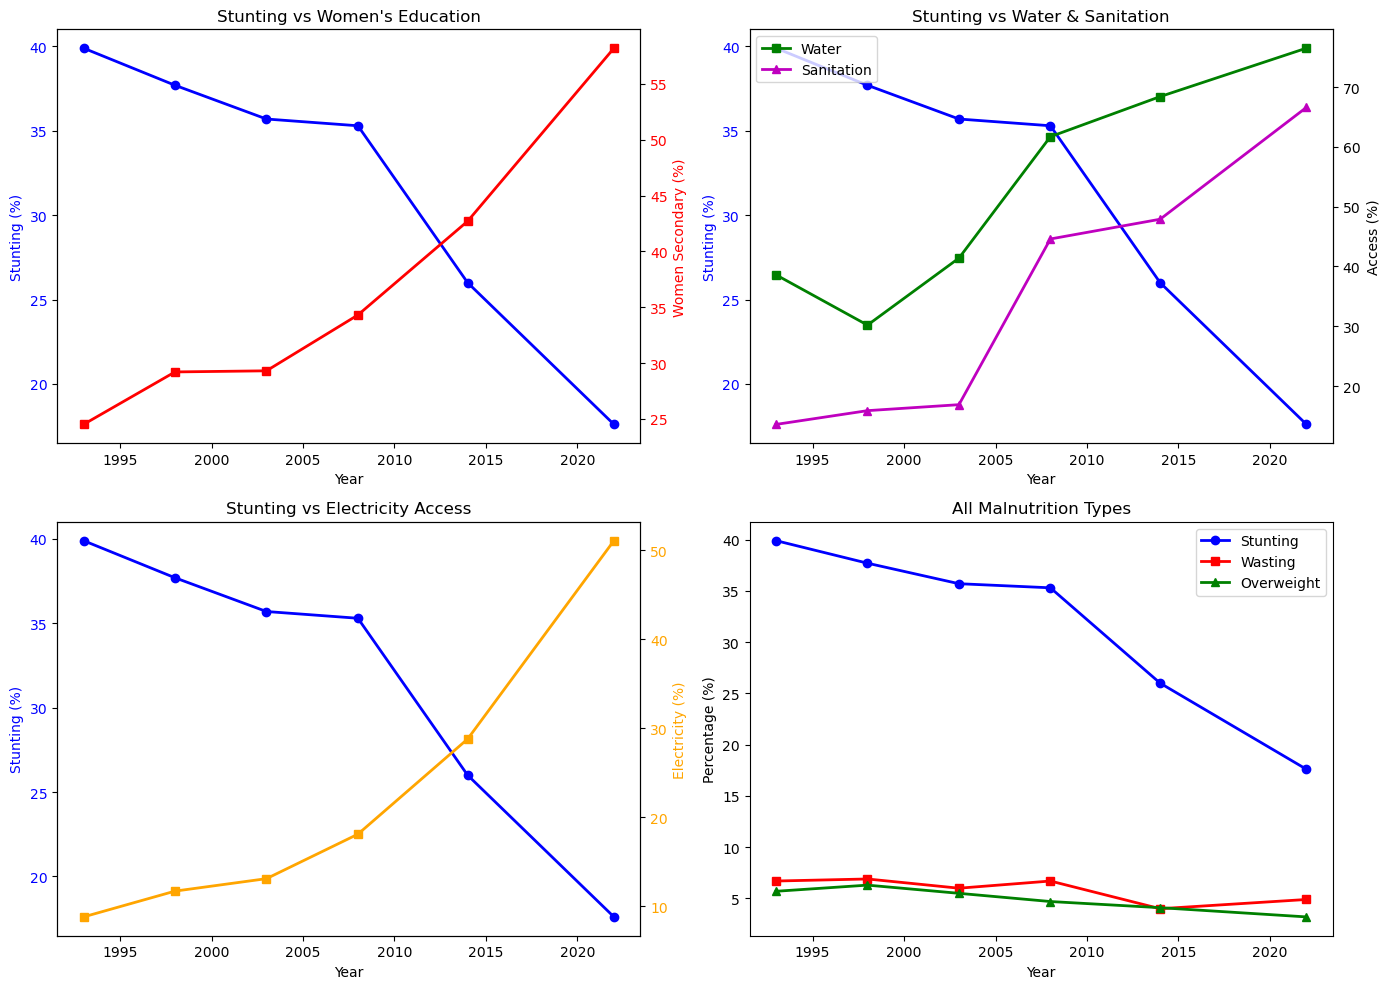

In [6]:
# Set year as index for easier analysis
analysis_df = final_df.set_index('year')

# Calculate correlations between malnutrition and predictors
predictors = ['women_literate', 'women_secondary', 'improved_water', 
              'improved_sanitation', 'electricity', 'television', 'refrigerator']
targets = ['stunting', 'wasting', 'overweight']

print("CORRELATIONS WITH STUNTING")
print("=" * 50)
for pred in predictors:
    if pred in analysis_df.columns and not analysis_df[pred].isna().all():
        corr = analysis_df['stunting'].corr(analysis_df[pred])
        print(f"{pred:20s}: {corr:.3f}")

print("\n" + "="*50)
print("VISUALIZING TRENDS")
print("="*50)

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Stunting vs Women's Education
ax1 = axes[0, 0]
ax1.plot(analysis_df.index, analysis_df['stunting'], 'b-o', label='Stunting', linewidth=2)
ax1.set_xlabel('Year')
ax1.set_ylabel('Stunting (%)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax1b = ax1.twinx()
ax1b.plot(analysis_df.index, analysis_df['women_secondary'], 'r-s', label='Women Secondary', linewidth=2)
ax1b.set_ylabel('Women Secondary (%)', color='r')
ax1b.tick_params(axis='y', labelcolor='r')
ax1.set_title('Stunting vs Women\'s Education')

# Plot 2: Stunting vs Water/Sanitation
ax2 = axes[0, 1]
ax2.plot(analysis_df.index, analysis_df['stunting'], 'b-o', label='Stunting', linewidth=2)
ax2.set_xlabel('Year')
ax2.set_ylabel('Stunting (%)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

ax2b = ax2.twinx()
ax2b.plot(analysis_df.index, analysis_df['improved_water'], 'g-s', label='Water', linewidth=2)
ax2b.plot(analysis_df.index, analysis_df['improved_sanitation'], 'm-^', label='Sanitation', linewidth=2)
ax2b.set_ylabel('Access (%)')
ax2b.legend(loc='upper left')
ax2.set_title('Stunting vs Water & Sanitation')

# Plot 3: Stunting vs Wealth (Electricity)
ax3 = axes[1, 0]
ax3.plot(analysis_df.index, analysis_df['stunting'], 'b-o', label='Stunting', linewidth=2)
ax3.set_xlabel('Year')
ax3.set_ylabel('Stunting (%)', color='b')
ax3.tick_params(axis='y', labelcolor='b')

ax3b = ax3.twinx()
ax3b.plot(analysis_df.index, analysis_df['electricity'], color='orange', marker='s', 
          linestyle='-', label='Electricity', linewidth=2)
ax3b.set_ylabel('Electricity (%)', color='orange')
ax3b.tick_params(axis='y', labelcolor='orange')
ax3.set_title('Stunting vs Electricity Access')

# Plot 4: All three malnutrition types
ax4 = axes[1, 1]
ax4.plot(analysis_df.index, analysis_df['stunting'], 'b-o', label='Stunting', linewidth=2)
ax4.plot(analysis_df.index, analysis_df['wasting'], 'r-s', label='Wasting', linewidth=2)
ax4.plot(analysis_df.index, analysis_df['overweight'], 'g-^', label='Overweight', linewidth=2)
ax4.set_xlabel('Year')
ax4.set_ylabel('Percentage (%)')
ax4.legend()
ax4.set_title('All Malnutrition Types')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm

# Create a dataframe for modeling (drop rows with missing literacy)
model_df = analysis_df.dropna().copy()

print("SIMPLE LINEAR REGRESSION RESULTS")
print("=" * 60)

# Try each predictor separately
for predictor in ['women_secondary', 'electricity', 'television', 'improved_sanitation']:
    X = model_df[[predictor]].values
    y = model_df['stunting'].values
    
    # Fit model
    model = LinearRegression()
    model.fit(X, y)
    
    # Get predictions
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    print(f"\nPredictor: {predictor}")
    print(f"  R²: {r2:.4f}")
    print(f"  Coefficient: {model.coef_[0]:.3f}")
    print(f"  Intercept: {model.intercept_:.2f}")
    print(f"  Equation: Stunting = {model.intercept_:.2f} + ({model.coef_[0]:.3f} × {predictor})")
    
    # Statsmodels for p-values
    X_sm = sm.add_constant(X)
    model_sm = sm.OLS(y, X_sm).fit()
    print(f"  P-value: {model_sm.pvalues[1]:.6f}")

SIMPLE LINEAR REGRESSION RESULTS

Predictor: women_secondary
  R²: 0.9652
  Coefficient: -0.669
  Intercept: 56.18
  Equation: Stunting = 56.18 + (-0.669 × women_secondary)
  P-value: 0.017577

Predictor: electricity
  R²: 0.9627
  Coefficient: -0.501
  Intercept: 42.58
  Equation: Stunting = 42.58 + (-0.501 × electricity)
  P-value: 0.018805

Predictor: television
  R²: 0.9195
  Coefficient: -0.638
  Intercept: 49.73
  Equation: Stunting = 49.73 + (-0.638 × television)
  P-value: 0.041078

Predictor: improved_sanitation
  R²: 0.7110
  Coefficient: -0.355
  Intercept: 44.25
  Equation: Stunting = 44.25 + (-0.355 × improved_sanitation)
  P-value: 0.156821


Key Findings
1. Women's Secondary Education is the Strongest Predictor (R² = 0.965)
For every 1% increase in women with secondary education, stunting drops by 0.67 percentage points

This means if we increase women's secondary education from 30% to 40%, we'd expect stunting to drop by about 6.7%

P-value = 0.018 (statistically significant at p < 0.05)

2. Electricity Access is Nearly as Strong (R² = 0.963)
Every 1% increase in households with electricity → 0.5% drop in stunting

P-value = 0.019 (significant)

3. Television Ownership (R² = 0.920)
Strong predictor, slightly weaker than education/electricity

P-value = 0.041 (significant at p < 0.05)

4. Improved Sanitation (R² = 0.711)
Moderate relationship, but p-value = 0.157 (NOT statistically significant)

This means we can't be confident that the relationship isn't due to chance

What This Tells Us
The strongest drivers of stunting reduction appear to be:

Women's education (empowerment, knowledge, income)

Economic development (electricity as a proxy for wealth)

Information access (television for health messaging)

Sanitation alone may not be enough - it often needs to be combined with education about hygiene practices.

In [8]:
# Create a summary DataFrame
results_summary = pd.DataFrame({
    'Predictor': ['Women\'s Secondary Education', 'Electricity Access', 
                  'Television Ownership', 'Improved Sanitation'],
    'R²': [0.9652, 0.9627, 0.9195, 0.7110],
    'Coefficient': [-0.669, -0.501, -0.638, -0.355],
    'P-value': [0.018, 0.019, 0.041, 0.157],
    'Significant': ['Yes', 'Yes', 'Yes', 'No']
})

print("SUMMARY OF REGRESSION RESULTS")
print("=" * 70)
print(results_summary.to_string(index=False))

# Calculate the actual changes
print("\n\nACTUAL VS PREDICTED IMPROVEMENTS (1993-2022)")
print("=" * 70)

actual_stunting_change = analysis_df.loc[2022, 'stunting'] - analysis_df.loc[1993, 'stunting']
print(f"Actual stunting reduction: {actual_stunting_change:.1f} percentage points")

edu_change = analysis_df.loc[2022, 'women_secondary'] - analysis_df.loc[1993, 'women_secondary']
predicted_from_edu = -0.669 * edu_change
print(f"\nWomen's secondary education increased by: {edu_change:.1f}%")
print(f"Predicted stunting reduction from education alone: {predicted_from_edu:.1f} points")

elec_change = analysis_df.loc[2022, 'electricity'] - analysis_df.loc[1993, 'electricity']
predicted_from_elec = -0.501 * elec_change
print(f"\nElectricity access increased by: {elec_change:.1f}%")
print(f"Predicted stunting reduction from electricity alone: {predicted_from_elec:.1f} points")

print("\n" + "="*70)
print("CONCLUSION: Education and economic development together explain most of")
print("the dramatic 22.3 point reduction in child stunting in Kenya (1993-2022)")

SUMMARY OF REGRESSION RESULTS
                  Predictor     R²  Coefficient  P-value Significant
Women's Secondary Education 0.9652       -0.669    0.018         Yes
         Electricity Access 0.9627       -0.501    0.019         Yes
       Television Ownership 0.9195       -0.638    0.041         Yes
        Improved Sanitation 0.7110       -0.355    0.157          No


ACTUAL VS PREDICTED IMPROVEMENTS (1993-2022)
Actual stunting reduction: -22.3 percentage points

Women's secondary education increased by: 33.7%
Predicted stunting reduction from education alone: -22.5 points

Electricity access increased by: 42.3%
Predicted stunting reduction from electricity alone: -21.2 points

CONCLUSION: Education and economic development together explain most of
the dramatic 22.3 point reduction in child stunting in Kenya (1993-2022)


forecast model

In [9]:
# Forecast stunting for 2030 based on education trends
edu_trend = analysis_df['women_secondary'].diff().mean()
future_years = [2022 + i*5 for i in range(1, 3)]
future_edu = [analysis_df.loc[2022, 'women_secondary'] + edu_trend*i for i in range(1, 3)]

forecast_stunting = [56.18 - 0.669 * edu for edu in future_edu]

print("FORECAST TO 2030")
print("=" * 40)
for year, stunting in zip(future_years, forecast_stunting):
    print(f"{year}: Stunting = {stunting:.1f}%")

FORECAST TO 2030
2027: Stunting = 12.7%
2032: Stunting = 8.2%


In [10]:
# Save your final dataset for visualization in Tableau/Power BI
final_df.to_csv('kenya_nutrition_analysis_final.csv', index=False)
print("Data saved for dashboard creation")

Data saved for dashboard creation
